In [12]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "..")

# Standard library imports
from itertools import combinations

# Scientific computing imports
import numpy as np
import pandas as pd
from scipy import sparse
from scipy.sparse import csr_matrix

# Plotting imports
import matplotlib.pyplot as plt

# Single-cell analysis imports
import anndata as ad
import mudata as md

# Local imports
from src.linked_data import LinkedData
from src.synthetic_data import generate_synthetic_mudata
from src.visualization import show_adjacency_matrix, plot_peptide_intensities
from session_info2 import session_info

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Demo of the new LinkedData class (MuData wrapper)

The `LinkedData` class was created to support the multi-layered feature space of MS-proteomics (precursors, peptides, proteins, genes). This notebook demonstrates its syntax and features on a small example dataset.

### 1. Example: LinkedData initialization and ingestion of a mudata object

In [13]:
# Get the example mudata
example_mudata = generate_synthetic_mudata()

ld = LinkedData()
ld.add_mudata(example_mudata)

/Users/lucas-diedrich/mamba/envs/mudata/lib/python3.11/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/lucas-diedrich/mamba/envs/mudata/lib/python3.11/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
INFO:src.linked_data:Using existing adjacency matrix from MuData varp['feature_mapping']


### 2. Example: show an adjacency matrix

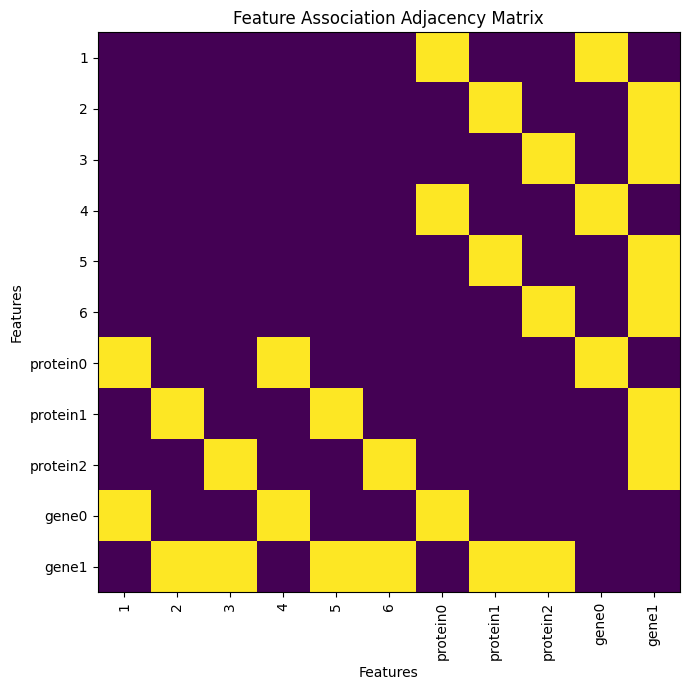

In [14]:
show_adjacency_matrix(ld.mdata)

### 3. Example construct linked data from PSM report

In [15]:
import alphapepttools as at 

In [16]:
at.data.get_data("diann_1.8.1_psm_report", output_dir="../data")

../data/diann_1.8.1_report_head.tsv already exists (0.0957937240600586 MB)


PosixPath('../data/diann_1.8.1_report_head.tsv')

/Users/lucas-diedrich/mamba/envs/mudata/lib/python3.11/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/lucas-diedrich/mamba/envs/mudata/lib/python3.11/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
INFO:src.linked_data:Using existing adjacency matrix from MuData varp['feature_mapping']


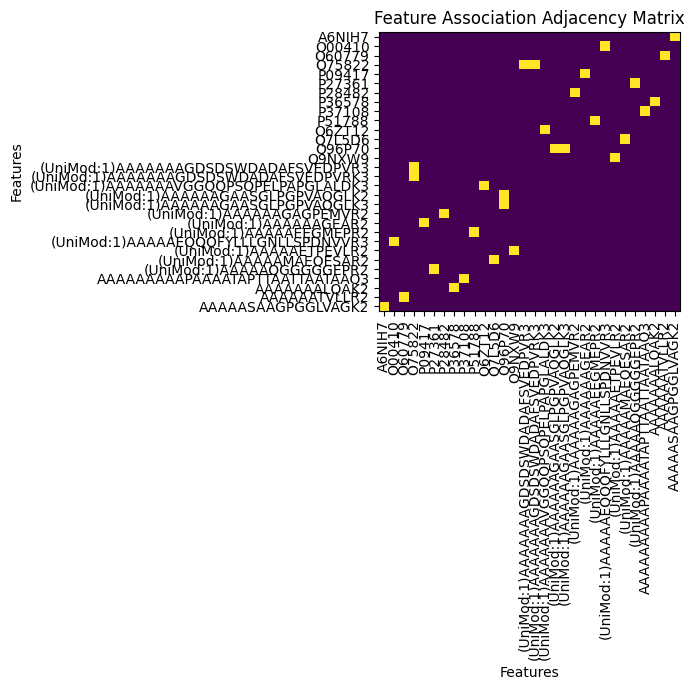

In [17]:
from src.psm_to_mudata import create_mudata_diann
prec_report_path = "../data/diann_1.8.1_report_head.tsv"
mudata_from_report = create_mudata_diann(prec_report_path, ["Precursor.Id", "Protein.Group"])

ld_from_report = LinkedData()
ld_from_report.add_mudata(mudata_from_report)
show_adjacency_matrix(ld_from_report.mdata)

### 4. Example for filtering based on a given feature index

In [18]:
ld.mdata.mod['proteins'].var
ld.get_associated_features('protein0', 'proteins')
ld.to_anndata('genes')

AnnData object with n_obs × n_vars = 5 × 1

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/Users/lucas-diedrich/mamba/envs/mudata/lib/python3.11/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/Users/lucas-diedrich/mamba/envs/mudata/lib/python3.11/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


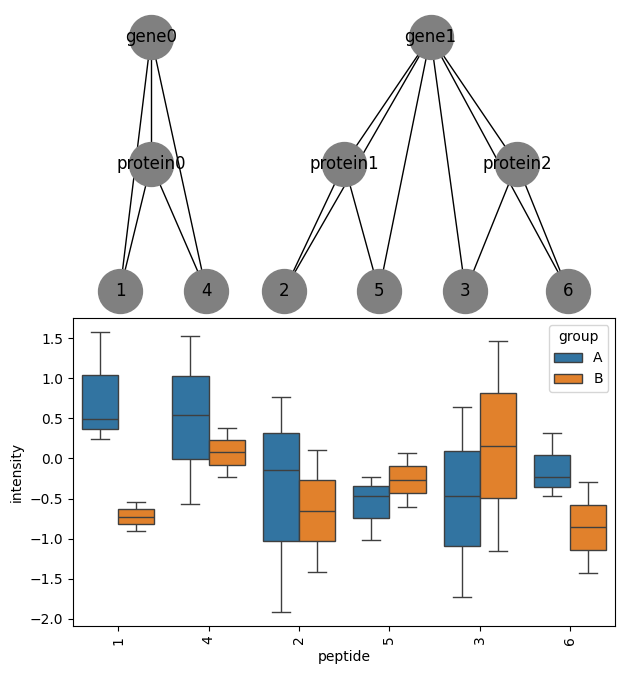

In [19]:
ld.mdata.mod["precursors"].obs["group"] = ["A", "A", "A", "B", "B"]

plot_peptide_intensities(
    ld.mdata, obs_group="group", level="precursors", varp_key="feature_mapping"
)
plt.show()

In [20]:
session_info()

/Users/lucas-diedrich/mamba/envs/mudata/lib/python3.11/site-packages/session_info2/__init__.py:124: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  and (v := getattr(pkg, "__version__", None))


Package,Version
anndata,0.11.3
numpy,2.4.4
pandas,2.3.3
scipy,1.15.2
matplotlib,3.10.1
mudata,0.3.1
alphapepttools,0.1.0
Component,Info
Python,"3.11.11 | packaged by conda-forge | (main, Mar 3 2025, 20:44:07) [Clang 18.1.8 ]"
OS,macOS-26.3-arm64-arm-64bit
